In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_circles
import matplotlib.pyplot as plt

In [3]:
np.random.seed(42)  # ensure same result on every run
X,y=make_circles(n_samples=500,noise=0.35,factor=0.1,random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,stratify=y)

In [4]:
X.shape

(500, 2)

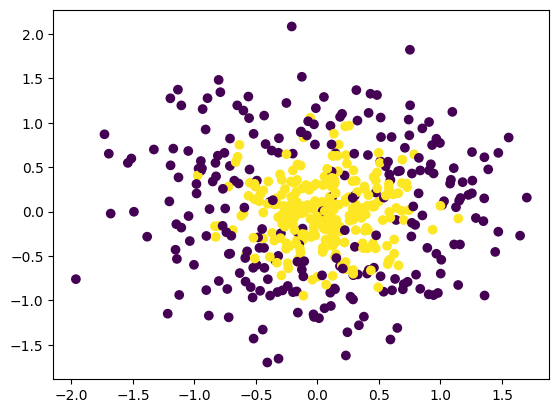

In [5]:
plt.scatter(X[:,0],X[:,1],c=y)

In [6]:
from sklearn.tree import DecisionTreeClassifier

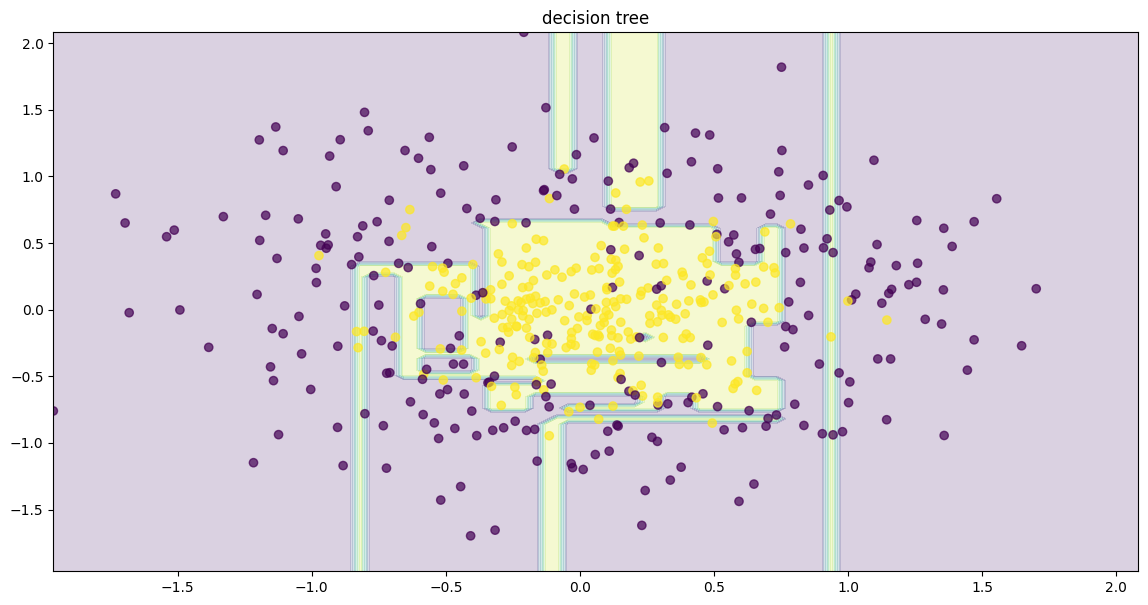

In [9]:
clf=DecisionTreeClassifier(random_state=42)
clf.fit(X_train,y_train)

plt.figure(figsize=(14,7))
x_range=np.linspace(X.min(),X.max(),100)
xx1,xx2=np.meshgrid(x_range,x_range)
y_hat=clf.predict(np.c_[xx1.ravel(),xx2.ravel()])
y_hat = y_hat.reshape(xx1.shape)
plt.contourf(xx1,xx2,y_hat,alpha=0.2)
plt.scatter(X[:,0], X[:,1], c=y, cmap='viridis', alpha=.7)
plt.title("decision tree")
plt.show()

In [10]:
from sklearn.ensemble import RandomForestClassifier

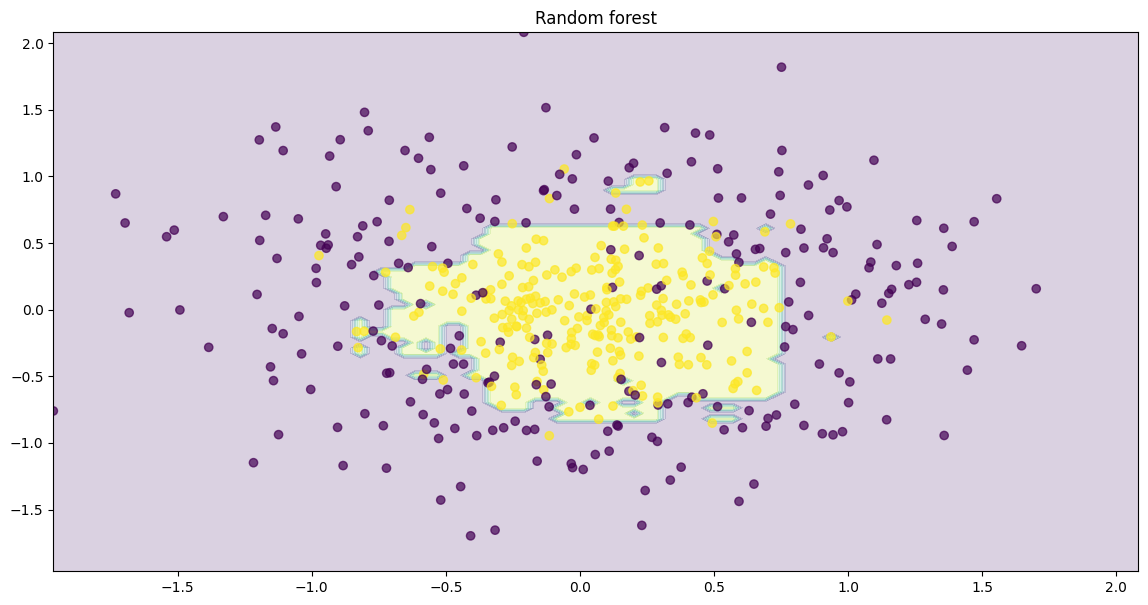

In [11]:
rf = RandomForestClassifier(n_estimators=500, random_state=42)
rf.fit(X_train, y_train)

plt.figure(figsize=(14,7))
x_range=np.linspace(X.min(),X.max(),100)
xx1,xx2=np.meshgrid(x_range,x_range)
y_hat=rf.predict(np.c_[xx1.ravel(),xx2.ravel()])
y_hat=y_hat.reshape(xx1.shape)
plt.contourf(xx1, xx2, y_hat, alpha=0.2)
plt.scatter(X[:,0], X[:,1], c=y, cmap='viridis', alpha=.7)
plt.title("Random forest")
plt.show()

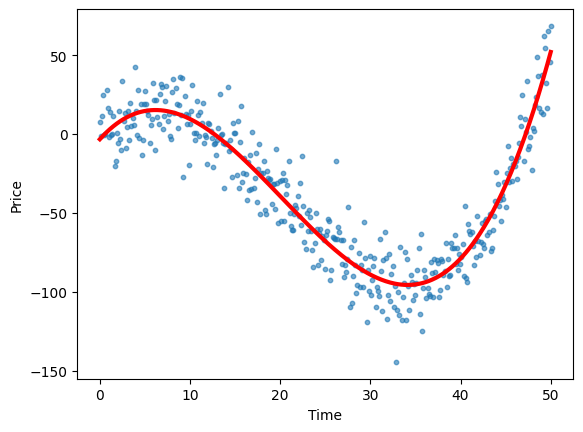

In [37]:
np.random.seed(42)

x = np.linspace(0, 50, 400)

# polynomial trend (up & down)
trend = 0.01*x**3 - 0.6*x**2 + 6*x

# noise (market randomness)
noise = np.random.normal(0, 15, size=len(x))

y = trend + noise

X=x.reshape(-1,1)
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=3)
X_poly = poly.fit_transform(X)

from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_poly, y)

y_pred = model.predict(X_poly)




plt.plot(X, y_pred, color='red', linewidth=3)
plt.scatter(x, y, s=10, alpha=0.6)
plt.xlabel("Time")
plt.ylabel("Price")
plt.show()